## 1. Persiapan Lingkungan dan Pemrosesan Data
Memuat pustaka inti seperti TensorFlow dan Pandas. Baris terakhir menjalankan pengecekan perangkat keras untuk memastikan sistem mendeteksi GPU. Komputasi matriks pada jaringan saraf tiruan akan jauh lebih optimal dan cepat jika menggunakan GPU dibandingkan CPU.

In [5]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# Memastikan TensorFlow mendeteksi GPU (CUDA)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


## 2 Pemisahan Fitur dan Label Target
Data dipisah menjadi dua jalur utama. Variabel X menampung 11 metrik profil (seperti jumlah pengikut dan panjang bio) sebagai bahan analisis. Variabel y menyimpan label kunci jawaban (0 untuk profil asli, 1 untuk bot). Tipe data dikonversi ke float32 agar kompatibel dengan standar presisi kalkulasi TensorFlow.

In [6]:
import pandas as pd
from pathlib import Path
local_csv = Path("master_dataset_cleaned.csv")
df = pd.read_csv(local_csv)
X = df.drop(columns=['fake']).values
y = df['fake'].values.astype('float32')

## 3 Pembagian Data Latih dan Uji (Train-Test Split)
Dataset dipecah dengan rasio 80:20. 80% data (train) digunakan sebagai buku pelajaran untuk melatih mesin, sementara 20% sisanya (test) disembunyikan. Data uji ini berfungsi sebagai soal ujian akhir untuk mengukur kecerdasan murni model dalam mengenali pola baru, bukan sekadar menghafal data lama.

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 4 Standarisasi Skala Data
Rentang angka pada setiap metrik disamakan menggunakan StandardScaler. Tanpa proses ini, metrik bernilai jutaan (seperti jumlah penayangan) akan mendominasi dan mengaburkan metrik bernilai kecil (seperti jumlah karakter bio). Scaler ini juga diekspor menjadi scaler.pkl agar metrik dari profil pengguna baru di masa depan mendapat perlakuan matematis yang sama.

In [8]:
from sklearn.preprocessing import StandardScaler
import joblib
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype('float32')
X_test_scaled = scaler.transform(X_test).astype('float32')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

## 5 Pengemasan Data (Batching & Shuffling)
Data dikemas ke dalam blok-blok memori kecil berisi 32 baris (batch_size = 32) dan urutannya diacak. Metode ini mencegah memori sistem kelebihan beban saat memproses ribuan data, sekaligus memaksa model untuk benar-benar memahami pola alih-alih menebak urutan data yang masuk.

In [9]:
import tensorflow as tf
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train)).shuffle(1024).batch(batch_size)

## 6 Pembangunan Arsitektur Jaringan Saraf
Membangun 'otak' dari model deteksi. Lapisan pertama menerima 11 sinyal metrik secara bersamaan. Sinyal tersebut diproses oleh 64 neuron buatan menggunakan fungsi aktivasi ReLU untuk menyaring nilai negatif. Disematkan juga lapisan Dropout(0.1) yang mematikan 10% neuron secara acak selama latihan, sebuah teknik krusial untuk mencegah overfitting."

In [10]:
inputs = tf.keras.Input(shape=(X_train_scaled.shape[1],))

## 7 Konversi Output Probabilitas
Lapisan paling ujung diakhiri dengan 1 neuron tunggal bersenjatakan fungsi aktivasi Sigmoid. Fungsinya adalah memeras seluruh hasil kalkulasi dari lapisan sebelumnya menjadi sebuah angka probabilitas yang solid: dari 0.0 (Sangat Yakin Asli) hingga 1.0 (Sangat Yakin Bot).

In [11]:
x = tf.keras.layers.Dense(64, activation='relu')(inputs) # Diperbesar jadi 64
x = tf.keras.layers.Dropout(0.1)(x)                      # Dropout diturunkan agar fokus belajar
x = tf.keras.layers.Dense(32, activation='relu')(x)      # Tambahan layer tengah
x = tf.keras.layers.Dense(16, activation='relu')(x)


Ruang terakhir hanya memiliki 1 neuron. Fungsi sigmoid memaksa hasil akhirnya menjadi bentuk probabilitas, yaitu angka antara 0.0 (Yakin Asli) hingga 1.0 (Yakin Bot).

In [12]:
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

## 8 Definisi Evaluasi & Perbaikan (Loss & Optimizer)

Kelas ini bertugas menghitung seberapa "salah" tebakan model. Variabel epsilon ditambahkan sebagai fitur keamanan. Jika model menebak probabilitas 0 mutlak, logaritma 0 di matematika akan menghasilkan error infinity. Epsilon mencegah hal itu terjadi. Ini adalah inti rumusnya. Jika jawaban aslinya adalah bot (1) tapi model menebak asli (0.1), hasil rumus ini (nilai loss) akan sangat besar, dan model akan "dihukum" berat untuk memperbaiki diri.

In [13]:
import datetime # Pastikan datetime di-import untuk penamaan folder log

# 1. Definisikan Custom Loss
class CustomBinaryCrossEntropy(tf.keras.losses.Loss):
    def __init__(self, name="custom_bce"):
        super().__init__(name=name)
        
    def call(self, y_true, y_pred):
        y_true = tf.reshape(y_true, tf.shape(y_pred))
        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        loss = - (y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        return tf.reduce_mean(loss)

loss_fn = CustomBinaryCrossEntropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

# 2. PERSIAPAN TENSORBOARD (Ini yang sebelumnya terlewat)
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_summary_writer = tf.summary.create_file_writer(f"logs/fit/{current_time}/train")

# 3. PERSIAPAN METRIK
train_acc_metric = tf.keras.metrics.BinaryAccuracy()
train_mae_metric = tf.keras.metrics.MeanAbsoluteError()

# 4. FUNGSI PELATIHAN INTI
@tf.function 
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        logits = model(x_batch, training=True)
        loss_value = loss_fn(y_batch, logits)
        
    grads = tape.gradient(loss_value, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    
    train_acc_metric.update_state(y_batch, logits)
    train_mae_metric.update_state(y_batch, logits)
    return loss_value

# 5. EKSEKUSI LOOP PELATIHAN
epochs = 150
print("🚀 Memulai proses latihan...")

for epoch in range(epochs):
    # Melatih model per batch
    for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
        loss_value = train_step(x_batch_train, y_batch_train)
    
    # Mengambil hasil kalkulasi metrik
    train_acc = train_acc_metric.result()
    train_mae = train_mae_metric.result()
    
    # Mencetak ke layar terminal
    print(f"Epoch {epoch+1:02d}/150 | Loss: {loss_value:.4f} | Akurasi: {train_acc:.4f} | MAE: {train_mae:.4f}")
    
    # Mencatat ke TensorBoard
    with train_summary_writer.as_default():
        tf.summary.scalar('accuracy', train_acc, step=epoch)
        tf.summary.scalar('mae', train_mae, step=epoch)
    
    # Mereset memori skor untuk epoch berikutnya
    train_acc_metric.reset_state()
    train_mae_metric.reset_state()

print("✅ Latihan Selesai!")

# (Opsional) Langsung simpan modelnya jika sudah selesai
model.save('fake_followers_model.keras')
print("💾 Model berhasil disimpan!")

🚀 Memulai proses latihan...
Epoch 01/150 | Loss: 0.3581 | Akurasi: 0.8579 | MAE: 0.3491
Epoch 02/150 | Loss: 0.1080 | Akurasi: 0.9422 | MAE: 0.1277
Epoch 03/150 | Loss: 0.0300 | Akurasi: 0.9430 | MAE: 0.0907
Epoch 04/150 | Loss: 0.1662 | Akurasi: 0.9481 | MAE: 0.0842
Epoch 05/150 | Loss: 0.0339 | Akurasi: 0.9491 | MAE: 0.0778
Epoch 06/150 | Loss: 0.1845 | Akurasi: 0.9503 | MAE: 0.0774
Epoch 07/150 | Loss: 0.0255 | Akurasi: 0.9503 | MAE: 0.0754
Epoch 08/150 | Loss: 0.0188 | Akurasi: 0.9514 | MAE: 0.0766
Epoch 09/150 | Loss: 0.0252 | Akurasi: 0.9541 | MAE: 0.0723
Epoch 10/150 | Loss: 0.0415 | Akurasi: 0.9546 | MAE: 0.0709
Epoch 11/150 | Loss: 0.0191 | Akurasi: 0.9546 | MAE: 0.0723
Epoch 12/150 | Loss: 0.1939 | Akurasi: 0.9536 | MAE: 0.0696
Epoch 13/150 | Loss: 0.3817 | Akurasi: 0.9564 | MAE: 0.0695
Epoch 14/150 | Loss: 0.1667 | Akurasi: 0.9582 | MAE: 0.0680
Epoch 15/150 | Loss: 0.1095 | Akurasi: 0.9584 | MAE: 0.0661
Epoch 16/150 | Loss: 0.0798 | Akurasi: 0.9582 | MAE: 0.0659
Epoch 17/150

## 9 Siklus Latihan Utama

Fungsi tf.GradientTape() ibarat kaset perekam. Kita menyuruh AI menebak kumpulan data 32 baris tadi (logits), lalu kita rekam proses perhitungannya dan kita nilai seberapa salah tebakannya (loss_value). Setelah tahu nilai salahnya (loss), kaset rekam tadi dimainkan mundur (tape.gradient) untuk mencari tahu neuron mana yang bikin salah. Lalu, optimizer (Adam) memperbaiki bobot jaringan tersebut agar tidak mengulangi kesalahan yang sama.

Proses baca-tebak-hukum-perbaiki tadi tidak hanya dilakukan sekali, tapi diulang 150 kali (150 siklus/epoch) pada seluruh dataset agar AI semakin ahli. Setiap selesai 1 epoch, skor akurasi (apakah > 85%) dan MAE (apakah < 0.02) dicatat ke dalam file log untuk digambar grafiknya nanti oleh TensorBoard. 

## 10 Ekspor Model
AI yang sudah lulus 150 kali pelatihan dan sudah pintar ini, lalu dibekukan bentuknya menjadi satu file bernama .keras agar siap digunakan oleh sistem web (plug and play).

In [14]:
model.save('fake_followers_model.keras')

🎓 MEMULAI UJIAN AKHIR (EVALUATION)
✅ Akurasi Ujian (Test Accuracy) : 96.76%
✅ Nilai Error Ujian (Test Loss) : 0.0767

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
📄 RAPOR DETAIL (Precision, Recall, F1-Score):
                  precision    recall  f1-score   support

Asli/Manusia (0)       0.96      0.98      0.97       517
         Bot (1)       0.98      0.95      0.97       470

        accuracy                           0.97       987
       macro avg       0.97      0.97      0.97       987
    weighted avg       0.97      0.97      0.97       987



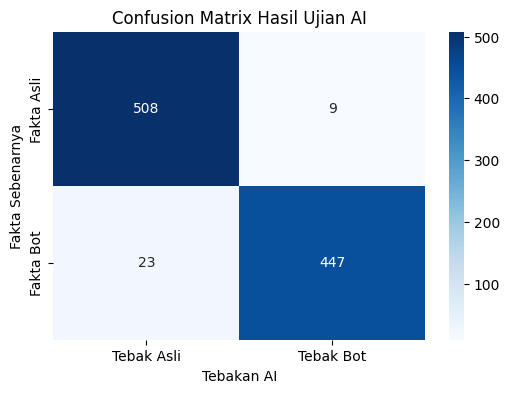

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("===========================================")
print("🎓 MEMULAI UJIAN AKHIR (EVALUATION)")
print("===========================================")

# 1. Mengevaluasi menggunakan data test yang disembunyikan (X_test_scaled)
# Kita kompilasi dulu modelnya dengan metrics standard sebelum evaluate
model.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"✅ Akurasi Ujian (Test Accuracy) : {test_accuracy * 100:.2f}%")
print(f"✅ Nilai Error Ujian (Test Loss) : {test_loss:.4f}\n")

# 2. Membuat Prediksi Ujian
y_pred_prob = model.predict(X_test_scaled)
y_pred_kelas = (y_pred_prob > 0.5).astype(int) # Jika probabilitas > 50%, vonis Bot

# 3. Mencetak Rapor Kelulusan (Classification Report)
print("📄 RAPOR DETAIL (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred_kelas, target_names=["Asli/Manusia (0)", "Bot (1)"]))

# 4. Menggambar Confusion Matrix (Diagram Kesalahan)
cm = confusion_matrix(y_test, y_pred_kelas)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Tebak Asli", "Tebak Bot"], 
            yticklabels=["Fakta Asli", "Fakta Bot"])
plt.title('Confusion Matrix Hasil Ujian AI')
plt.ylabel('Fakta Sebenarnya')
plt.xlabel('Tebakan AI')
plt.show()